# Wood Stork Observations Using the eBird API

This notebook retrieves recent Wood Stork observations from the eBird API, compares observation counts across selected southeastern states, and summarizes the locations represented in the returned sample.

The code is organized as a sequence of setup, retrieval, cleaning, and visualization steps.

In [ ]:
# os reads the API key from the computer's environment variables.
import os
# requests sends HTTP requests to the eBird API.
import requests
# pandas stores and analyzes the API results in tabular form.
import pandas as pd
# matplotlib creates charts from the processed data.
import matplotlib.pyplot as plt
# folium creates an interactive map with a geographic background layer.
import folium

## API Setup

The eBird API provides bird-observation data through web requests. A free API key is required so the service can authenticate each request.

Request a key at: https://ebird.org/api/keygen  

Either set the `EBIRD_API_KEY` environment variable before starting the notebook, or enter the key securely when the setup cell prompts you. The Wood Stork species code used by eBird is `woosto`.

In [37]:
# SETUP CELL: Configure the eBird API key

# getpass lets us enter a key without displaying it in the notebook output.
from getpass import getpass

# Prefer an environment variable so the API key is not saved in this file.
API_KEY = os.environ.get("EBIRD_API_KEY")
if not API_KEY:
    # Fall back to a hidden prompt when the environment variable is unavailable.
    API_KEY = getpass("Enter your eBird API key (input hidden): ").strip()
if not API_KEY:
    # Stop early with a clear message instead of making an unauthenticated request.
    raise RuntimeError(
        "No eBird API key was provided. Set EBIRD_API_KEY or enter your key when prompted."
    )
# eBird's code for Wood Stork is used in each species-specific endpoint.
SPECIES_CODE = "woosto"
# All API endpoints used in the notebook share this base URL.
BASE_URL = "https://api.ebird.org/v2"
# The API expects the key in the X-eBirdApiToken request header.
HEADERS = {"X-eBirdApiToken": API_KEY}

# Retrieve observations and provide useful errors when the API request fails.
def get_observations(url, params):
    # params adds query-string options such as the date range and result limit.
    response = requests.get(url, headers=HEADERS, params=params)
    try:
        # Convert HTTP errors into an exception that identifies the failed request.
        response.raise_for_status()
    except requests.HTTPError as exc:
        try:
            # eBird usually returns helpful error details as JSON.
            details = response.json()
        except ValueError:
            # Use plain response text if the error body is not valid JSON.
            details = response.text
        raise RuntimeError(
            f"eBird API request failed ({response.status_code}): {details}"
        ) from exc

    # Decode the successful response and verify the expected list format.
    observations = response.json()
    if not isinstance(observations, list):
        raise RuntimeError(
            f"Expected a list of observations, got {type(observations).__name__}: {observations}"
        )
    return observations

In [38]:
# Step 1: Test the API - Recent Wood Stork Observations


# Request the most recent Wood Stork observations reported anywhere in the US.
url = f"{BASE_URL}/data/obs/US/recent/{SPECIES_CODE}"
# Limit this test request to ten records so it is quick and easy to inspect.
params = {"maxResults": 10}

data = get_observations(url, params)
print(f"Number of recent observations retrieved: {len(data)}")

# Confirm that at least one record was returned before indexing the list.
if not data:
    raise RuntimeError("The eBird API returned no recent Wood Stork observations.")
# Display selected fields from the first observation as a quick data check.
first_obs = data[0]
print("Date:", first_obs.get("obsDt"))
print("Common name:", first_obs.get("comName"))
print("Scientific name:", first_obs.get("sciName"))
print("Location:", first_obs.get("locName"))
print("State/Province:", first_obs.get("subnational1Code"))
print("How many:", first_obs.get("howMany"))


Number of recent observations retrieved: 10
Date: 2026-10-07 19:55
Common name: Wood Stork
Scientific name: Mycteria americana
Location: Parrish Park/Max Brewer Causeway
State/Province: None
How many: 2


            State  Observations
0         Florida           200
1         Georgia           128
2  South Carolina           200
3  North Carolina            30
4         Alabama            25
5     Mississippi            26
6       Louisiana            29
7           Texas           148


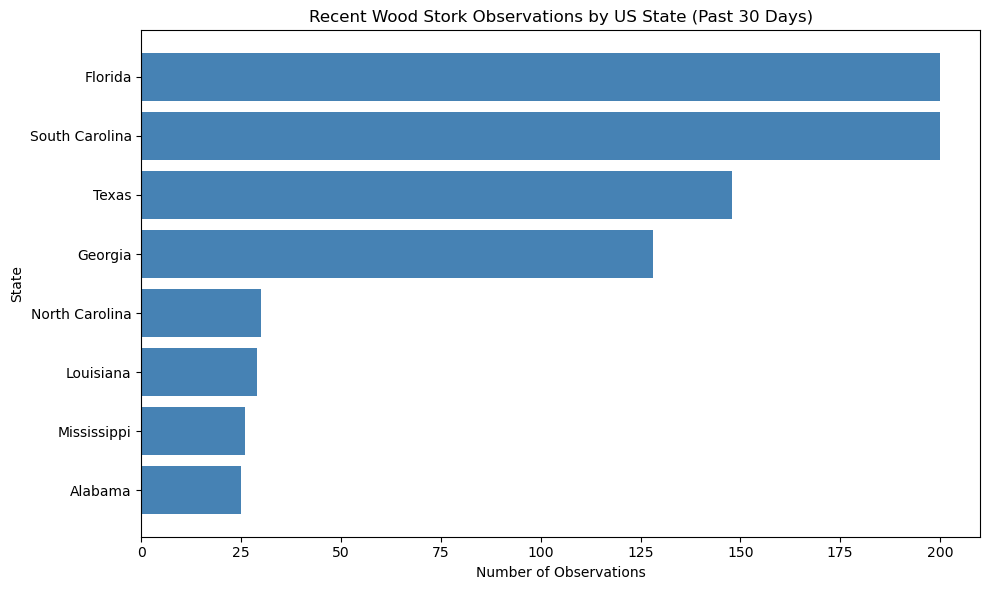

In [39]:

# Step 2: Recent Observations by Southeastern US State
# Each state code is the geographic identifier expected by the eBird API.


states = {
    "Florida": "US-FL",
    "Georgia": "US-GA",
    "South Carolina": "US-SC",
    "North Carolina": "US-NC",
    "Alabama": "US-AL",
    "Mississippi": "US-MS",
    "Louisiana": "US-LA",
    "Texas": "US-TX"
}

# Store one summary record per state before converting the results to a DataFrame.
state_counts = []

# Query the same species and time window for each state.
for state_name, state_code in states.items():
    url = f"{BASE_URL}/data/obs/{state_code}/recent/{SPECIES_CODE}"
    params = {"maxResults": 200, "back": 30}  # past 30 days
    obs = get_observations(url, params)
    # Count returned records; this measures observations, not individual birds.
    count = len(obs)
    state_counts.append({"State": state_name, "Observations": count})

# Convert the list of dictionaries into a table for display and plotting.
state_df = pd.DataFrame(state_counts)
print(state_df)

# Sort the bars so the chart is easier to compare from low to high.
# Bar chart: recent Wood Stork observations by state
state_df_sorted = state_df.sort_values("Observations", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(state_df_sorted["State"], state_df_sorted["Observations"], color="steelblue")
plt.title("Recent Wood Stork Observations by US State (Past 30 Days)")
plt.xlabel("Number of Observations")
plt.ylabel("State")
plt.tight_layout()
plt.show()



In [40]:
# Step 3: Larger Sample - Build a Structured DataFrame

url = f"{BASE_URL}/data/obs/US/recent/{SPECIES_CODE}"
params = {"maxResults": 200, "back": 30}

# Retrieve up to 200 observations from the most recent 30-day period.
all_obs = get_observations(url, params)

# Select useful fields from each API record for a compact analysis table.
records = []
for obs in all_obs:
    records.append({
        "date": obs.get("obsDt"),
        "common_name": obs.get("comName"),
        "scientific_name": obs.get("sciName"),
        "location": obs.get("locName"),
        "state": obs.get("subnational1Code"),
        "how_many": obs.get("howMany"),
        "latitude": obs.get("lat"),
        "longitude": obs.get("lng")
    })

# Create a DataFrame so the observations can be cleaned and summarized with pandas.
df = pd.DataFrame(records)
# Convert text timestamps into datetime values for time-based analysis later.
df["date"] = pd.to_datetime(df["date"])
print(f"Total observations in sample: {len(df)}")
print(df.head())



Total observations in sample: 200
                 date common_name     scientific_name  \
0 2026-10-07 19:55:00  Wood Stork  Mycteria americana   
1 2026-10-07 18:41:00  Wood Stork  Mycteria americana   
2 2026-10-07 17:49:00  Wood Stork  Mycteria americana   
3 2026-10-07 17:48:00  Wood Stork  Mycteria americana   
4 2026-10-07 17:24:00  Wood Stork  Mycteria americana   

                           location state  how_many   latitude  longitude  
0  Parrish Park/Max Brewer Causeway  None       2.0  28.623706 -80.794487  
1  Huntington Beach SP--Mullet Pond  None      14.0  33.507587 -79.069181  
2         Lake house Ocala preserve  None       1.0  29.225879 -82.210709  
3                       Lake Howell  None       1.0  28.639877 -81.309439  
4                 Burton 4-H Center  None       2.0  32.007428 -80.851511  


In [41]:

# Step 4: Map the Top 10 Wood Stork Observation Locations
# Folium adds an interactive OpenStreetMap background so the observation
# locations can be viewed in their geographic context.
import folium
from IPython.display import display


# Count observations and calculate one representative coordinate per location.
location_summary = (
    df.dropna(subset=["location", "latitude", "longitude"])
    .groupby("location", as_index=False)
    .agg(
        observations=("location", "size"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        dates=(
            "date",
            lambda dates: "<br>".join(
                sorted(dates.dt.strftime("%Y-%m-%d").unique())
            ),
        ),
    )
    .sort_values("observations", ascending=False)
    .head(10)
)

print(location_summary[["location", "observations"]])

# Center the map on the average coordinates of the selected locations.
map_center = [
    location_summary["latitude"].mean(),
    location_summary["longitude"].mean(),
]
observation_map = folium.Map(
    location=map_center,
    zoom_start=6,
    tiles="OpenStreetMap",
)

# Add one clickable marker for each location.
for _, row in location_summary.iterrows():
    popup_text = (
        f"<b>{row['location']}</b><br>"
        f"Observations: {row['observations']}<br>"
        f"Dates observed:<br>{row['dates']}<br>"
        f"Coordinates: {row['latitude']:.4f}, {row['longitude']:.4f}"
    )
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6 + row["observations"] * 2,
        color="darkred",
        fill=True,
        fill_color="orange",
        fill_opacity=0.8,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['location']} ({row['observations']} observations)",
    ).add_to(observation_map)

# Zoom the map so all ten locations are visible.
observation_map.fit_bounds(
    [
        [location_summary["latitude"].min(), location_summary["longitude"].min()],
        [location_summary["latitude"].max(), location_summary["longitude"].max()],
    ]
)
# Explicitly display the HTML/JavaScript map in the notebook output.
display(observation_map)

                                              location  observations
144                    Rivers Edge Public Nature Trail             2
179                           Sweetwater Wetlands Park             2
120              M&M Dairy (Port Jacksonville Parkway)             2
87                    Huntington Beach SP--Mullet Pond             2
4    1187 Haig Point Rd, Daufuskie Island US-SC 32....             1
5    1401 SH-100, Port Isabel US-TX 26.07171, -97.2...             1
6    14301–14399 Fruitville Rd, Sarasota US-FL 27.3...             1
7    160 Gem Lake Dr, Maitland US-FL 28.61363, -81....             1
8    1684–2140 Greenall Rd, Summerton US-SC 33.5334...             1
9    21532–21538 CR-675, Myakka City US-FL 27.51956...             1
